In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\human\Desktop\DAy 6\student_performance.csv")

# Create Target Column

In [3]:
df["Pass"] = (df["Final_Score"] >= 60).astype(int)

# Features

In [4]:
X = df[["Attendance", "Assignment_Score",
        "Midterm_Score", "Final_Score"]]

# Target

In [5]:
y = df["Pass"]


# Feature Scaling

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)


# Base Model
logistic regression

In [8]:
base_model = LogisticRegression()

base_model.fit(X_train, y_train)

base_pred = base_model.predict(X_test)

base_accuracy = accuracy_score(y_test, base_pred)
base_precision = precision_score(y_test, base_pred)
base_recall = recall_score(y_test, base_pred)
base_f1 = f1_score(y_test, base_pred)


# Hyperparameter Tuning

In [9]:
params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(),
    params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_


c:\Users\human\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


# Predictions

In [10]:
tuned_pred = best_model.predict(X_test)


# Metrics

In [11]:
tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred)
tuned_recall = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)


# ROC AUC

In [12]:
roc_auc = roc_auc_score(y_test, tuned_pred)

print("Best Parameters:")
print(grid.best_params_)

print("\nBase Accuracy:", base_accuracy)
print("Tuned Accuracy:", tuned_accuracy)

print("ROC AUC:", roc_auc)


Best Parameters:
{'C': 10, 'solver': 'liblinear'}

Base Accuracy: 1.0
Tuned Accuracy: 1.0
ROC AUC: nan


c:\Users\human\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


# Comparison Table

In [13]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Base Model": [
        base_accuracy,
        base_precision,
        base_recall,
        base_f1
    ],
    "Tuned Model": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

print(comparison)



      Metric  Base Model  Tuned Model
0   Accuracy         1.0          1.0
1  Precision         1.0          1.0
2     Recall         1.0          1.0
3   F1 Score         1.0          1.0


# Visualization 1- comparison graph

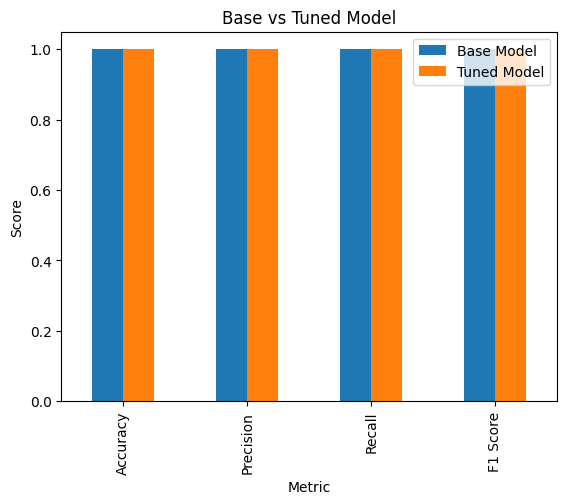

In [14]:
comparison.set_index("Metric").plot(kind="bar")

plt.title("Base vs Tuned Model")
plt.ylabel("Score")
plt.show()

# Visualization 2-bar graph


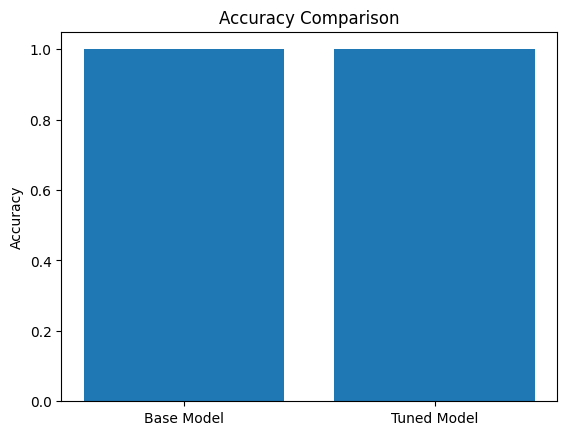

In [15]:
plt.bar(
    ["Base Model", "Tuned Model"],
    [base_accuracy, tuned_accuracy]
)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()
